# 05 · УЧП с двумя и тремя пространственными измерениями

Навье-Стокс (след за цилиндром), срез турбулентности JHTDB с точными производными, модельная температура почвы. Оси: `x0` = t, затем пространственные оси в порядке, напечатанном в описании набора.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


## `ns` · Навье-Стокс, след за цилиндром (Re = 100)

ns: Navier-Stokes, cylinder wake (Re = 100)
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (50, 20, 36); variables: u, v, p
  t: [0, 4.9], 50 points
  y: [-1.592, 1.51], 20 points
  x: [1, 5.949], 36 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * dp/dx2{power: 1.0} + 0.01 * d^2u/dx2^2{power: 1.0} + 0.01 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * dp/dx1{power: 1.0} + 0.01 * d^2v/dx2^2{power: 1.0} + 0.01 * d^2v/dx1^2{power: 1.0} = dv/dx0{power: 1.0}
    -1.0 * dv/dx1{power: 1.0} = du/dx2{power: 1.0}
  notes: Axes (t, y, x): dx1 = d/dy, dx2 = d/dx. Two momentum equations (nu = 0.01) and continuity. Default subset = gate.py's (36k points); 'full50' is the old ns.py window (250k points per variable).


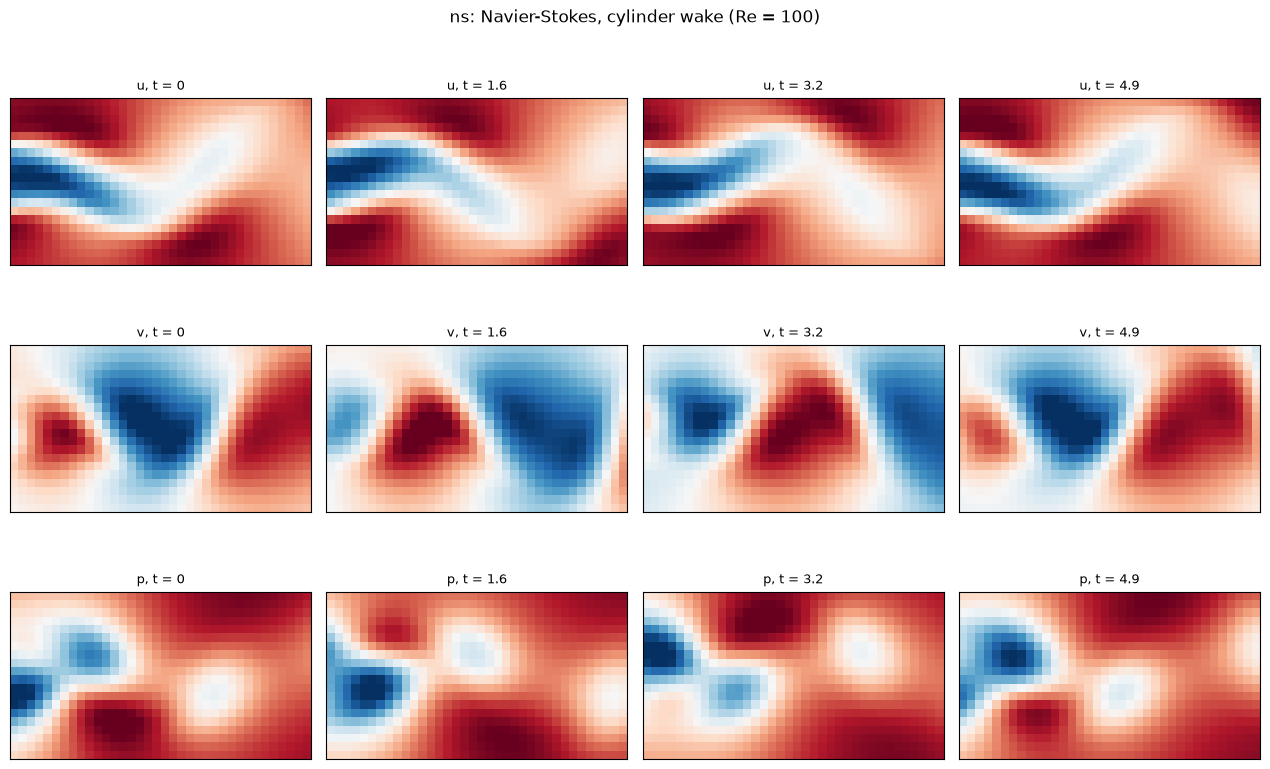

In [2]:
p = datasets.load('ns')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('ns', noise_levels=[0, 1])
print_check(p, report)

ns: Navier-Stokes, cylinder wake (Re = 100)
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (50, 20, 36); variables: u, v, p
  t: [0, 4.9], 50 points
  y: [-1.592, 1.51], 20 points
  x: [1, 5.949], 36 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * dp/dx2{power: 1.0} + 0.01 * d^2u/dx2^2{power: 1.0} + 0.01 * d^2u/dx1^2{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * dp/dx1{power: 1.0} + 0.01 * d^2v/dx2^2{power: 1.0} + 0.01 * d^2v/dx1^2{power: 1.0} = dv/dx0{power: 1.0}
    -1.0 * dv/dx1{power: 1.0} = du/dx2{power: 1.0}
  notes: Axes (t, y, x): dx1 = d/dy, dx2 = d/dx. Two momentum equations (nu = 0.01) and continuity. Default subset = gate.py's (36k points); 'full50' is the old ns.py window (250k points per variable).

=== noise 0 % ===
R^2 of the true structure: 0.999253   (du/dx0{power: 1.0})
  term       

Запуск на `ns` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run ns`.

## `jhtdb_plane` · Изотропная турбулентность, 2-D срез JHTDB

jhtdb_plane: Isotropic turbulence, 2-D slice of JHTDB
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (40, 48, 48); variables: u, v
  t: [0.5, 0.578], 40 points
  y: [1, 3.307], 48 points
  x: [1, 3.307], 48 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * w{power: 1.0} * u_z{power: 1.0} + -1.0 * p_x{power: 1.0} + 1.0 * nu_lap_u{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * w{power: 1.0} * v_z{power: 1.0} + -1.0 * p_y{power: 1.0} + 1.0 * nu_lap_v{power: 1.0} = dv/dx0{power: 1.0}
  notes: 48 x 48 slice (stride 8 of the DNS grid), 40 frames. Too coarse for numerical derivatives (aliased), so the exact server-side gradients are passed instead; out-of-plane and pressure terms enter as exact tokens. Artificial noise is unsupported with these supplied derivatives; use noise=0.


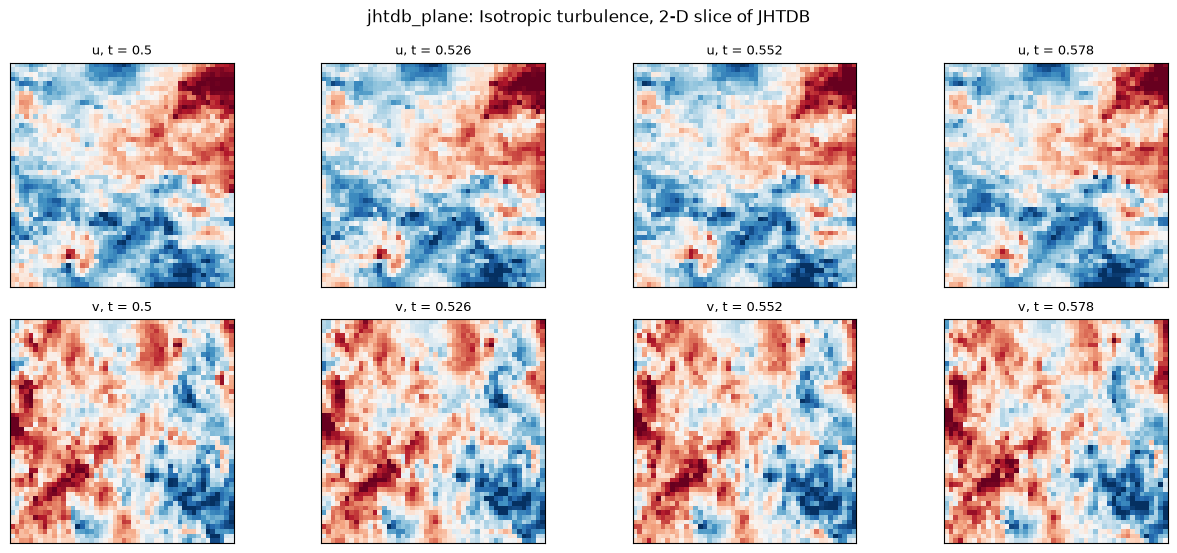

In [4]:
p = datasets.load('jhtdb_plane')
print(p.summary())
plot_problem(p); plt.show()

JHTDB: проверка и поиск только при noise=0. Переданные DNS-производные и внешние поля согласованы с чистыми наблюдениями; шумовой эксперимент требует заново вычисленного согласованного набора.

In [5]:
p, report = check('jhtdb_plane', noise_levels=[0])
print_check(p, report)

jhtdb_plane: Isotropic turbulence, 2-D slice of JHTDB
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, y, x; data shape: (40, 48, 48); variables: u, v
  t: [0.5, 0.578], 40 points
  y: [1, 3.307], 48 points
  x: [1, 3.307], 48 points
  truth:
    -1.0 * u{power: 1.0} * du/dx2{power: 1.0} + -1.0 * v{power: 1.0} * du/dx1{power: 1.0} + -1.0 * w{power: 1.0} * u_z{power: 1.0} + -1.0 * p_x{power: 1.0} + 1.0 * nu_lap_u{power: 1.0} = du/dx0{power: 1.0}
    -1.0 * u{power: 1.0} * dv/dx2{power: 1.0} + -1.0 * v{power: 1.0} * dv/dx1{power: 1.0} + -1.0 * w{power: 1.0} * v_z{power: 1.0} + -1.0 * p_y{power: 1.0} + 1.0 * nu_lap_v{power: 1.0} = dv/dx0{power: 1.0}
  notes: 48 x 48 slice (stride 8 of the DNS grid), 40 frames. Too coarse for numerical derivatives (aliased), so the exact server-side gradients are passed instead; out-of-plane and pressure terms enter as exact tokens. Artificial noise is unsupported with these supplied derivatives; use noise=0.

=== noise 0 % ===
R^2 of the tru

Запуск на `jhtdb_plane` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run jhtdb_plane`.

## `heat_solar_2d` · Теплоперенос в почве при солнечном нагреве, 2-D

heat_solar_2d: Heat in soil under solar forcing, 2-D
  class: PDE, 2 space dimensions, source: synthetic
  axes: t, x, y; data shape: (144, 51, 51); variables: u
  t: [300, 1.719e+05], 144 points
  x: [-0.375, 0.375], 51 points
  y: [-1.5, 0], 51 points
  truth: unknown
  notes: 2-D version of heat_solar_1d (576 x 51 x 51 before striding in t).


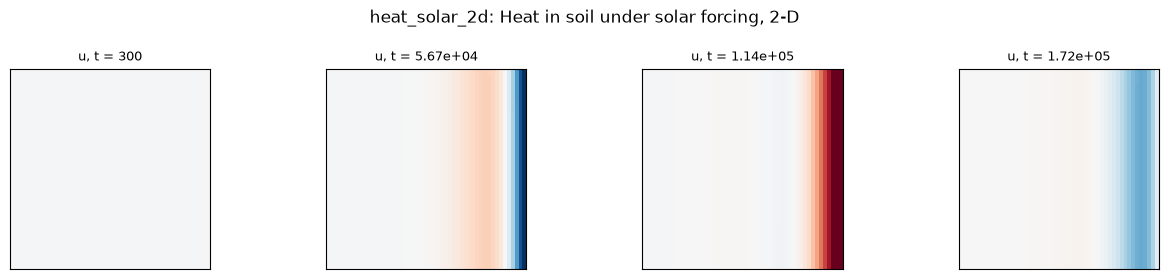

In [6]:
p = datasets.load('heat_solar_2d')
print(p.summary())
plot_problem(p); plt.show()

Запуск на `heat_solar_2d` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run heat_solar_2d`.

## `heat_laser` · Теплопроводность с движущимся лазерным источником, 3-D

heat_laser: Heat equation with a moving laser source, 3-D
  class: PDE, 3 space dimensions, source: synthetic
  axes: t, x, y, z; data shape: (20, 51, 51, 3); variables: u
  t: [0, 1.9], 20 points
  x: [0, 0.1], 51 points
  y: [0, 0.1], 51 points
  z: [0, 0.001], 3 points
  truth: unknown
  notes: Only 3 points along z and 20 in t, so z- and t-derivatives are crude. The source L is laser.npy (t, x, y), assumed uniform in z -- the old script rebuilt it from a formula with mismatched axes. No truth is scored.

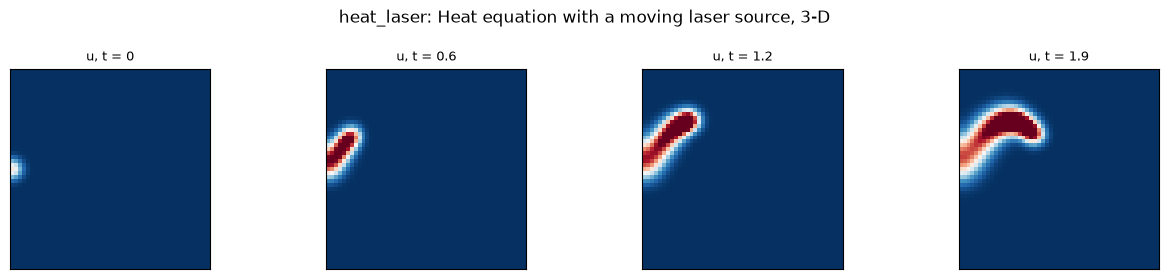

In [7]:
p = datasets.load('heat_laser')
print(p.summary())
plot_problem(p); plt.show()

Запуск на `heat_laser` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run heat_laser`.

## `darcy` · Явный пропуск

Исходные файлы Darcy отсутствуют в поставке. Загрузчик выдаёт FileNotFoundError; поиск и проверка не запускаются. Это отсутствие данных, а не неудача алгоритма.